<a href="https://colab.research.google.com/github/nuranferhan/ML-projects/blob/main/Heart%20Failure%20Prediction/heart_failure_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Heart Failure Prediction ML Project**

**Kalp Yetmezliği Tahmini Makine Öğrenmesi Projesi**

Kalp yetmezliği, dünya çapında önemli bir sağlık sorunu olarak karşımıza çıkmaktadır. Her yıl milyonlarca insan, bu durumun neden olduğu komplikasyonlar nedeniyle yaşamını yitirmekte veya yaşam kalitesinde ciddi bir düşüşle karşı karşıya kalmaktadır. Erken teşhis ve doğru müdahale, bu hastalığın yönetiminde kritik bir rol oynamaktadır. Ancak, kalp yetmezliğinin karmaşık ve çok faktörlü doğası, geleneksel tanı ve tedavi yöntemlerinin etkinliğini sınırlayabilmektedir.

Bu bağlamda, makine öğrenimi ve veri analitiği gibi modern teknolojiler, sağlık sektöründe devrim niteliğinde yenilikler sunmaktadır. Büyük veri setleri üzerinde yapılan analizler, kalp yetmezliği gibi hastalıkların erken teşhisi ve risk faktörlerinin belirlenmesi için güçlü bir temel sağlamaktadır. Bu projede, "Heart Failure Prediction" veri seti kullanılarak, bireylerin kalp yetmezliği riskini tahmin etmek için bir makine öğrenimi modeli geliştirilmiştir.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder

# **1. Veri Temizleme:**

Veri temizleme süreci, eksik değerlerin giderilmesi ve kategorik verilerin sayısal verilere dönüştürülmesi adımlarını içerir.

In [2]:
# Veri setini yükleyelim
file_path = '/content/sample_data/heart.csv'
df = pd.read_csv(file_path)

# Veri setinin genel durumu
df_head = df.head()
df_info = df.info()
df_summary = df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [3]:
# Gereksiz sütunların kaldırılması
if 'Unnamed: 32' in df.columns:
    df = df.drop(columns=['Unnamed: 32'])

# Hedef değişkeni sayısal forma dönüştürme
df['HeartDisease'] = df['HeartDisease'].map({0: 'No', 1: 'Yes'})

# Eksik veri kontrolü
missing_values = df.isnull().sum()

* **Eksik Değerlerin İşlenmesi:** Veri setindeki eksik veriler kontrol edilmiş ve cholesterol_maxHR_ratio ile age_oldpeak_ratio gibi yeni türetilen sütunlarda inf (sonsuz) değerleri bulunmuştur. Bu tür değerler, sıfıra bölme işlemi sonucu oluşmuştur. Inf ve NaN değerler, her iki sütun için de replace([np.inf, -np.inf], np.nan) yöntemi ile NaN olarak değiştirilmiştir. Ardından bu NaN değerler, ilgili sütunların medyan değeri ile doldurulmuştur (fillna(df['cholesterol_maxHR_ratio'].median(), inplace=True)).

In [4]:
# Label encoding for binary categorical features
label_encoder = LabelEncoder()

# Encoding 'Sex' and 'ExerciseAngina'
df['Sex'] = label_encoder.fit_transform(df['Sex'])  # M -> 1, F -> 0
df['ExerciseAngina'] = label_encoder.fit_transform(df['ExerciseAngina'])  # Yes -> 1, No -> 0

# One-hot encoding for nominal categorical features
df = pd.get_dummies(df, columns=['ChestPainType', 'RestingECG', 'ST_Slope'], drop_first=True)

* **Kategorik Verilerin Kodlanması:** Kategorik değişkenler, modelin anlayabileceği sayısal değerlere dönüştürülmüştür. Sex ve ExerciseAngina sütunları için **Label Encoding** kullanılmıştır. Bu işlemle, "Male" ve "Female" gibi metin değerleri 1 ve 0'a dönüştürülmüş, "Yes" ve "No" gibi kategoriler de benzer şekilde kodlanmıştır. Ayrıca, nominal kategorik veriler (örneğin, ChestPainType, RestingECG, ST_Slope) için **One-Hot Encoding** yapılmıştır.

# **2. Keşifsel Veri Analizi (EDA):**

Veri seti üzerine keşifsel analiz yapılarak, verinin genel dağılımı hakkında bilgi edinilmiştir.

<ipython-input-5-caeacacba97c>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='HeartDisease', palette='viridis')


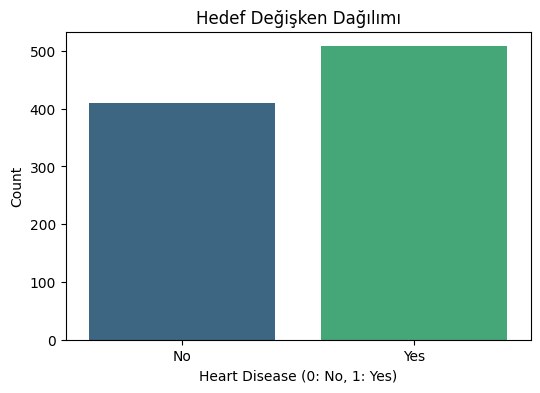

In [5]:
# Hedef değişken dağılımı
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='HeartDisease', palette='viridis')
plt.title('Hedef Değişken Dağılımı')
plt.xlabel('Heart Disease (0: No, 1: Yes)')
plt.ylabel('Count')
plt.show()

* **Hedef Değişken Dağılımı:** HeartDisease hedef değişkeninin sınıf dağılımı, sns.countplot() ile görselleştirilmiştir. HeartDisease değişkeni 0 (no) ve 1 (yes) sınıflarına sahip olup, genellikle kalp hastalığı olan bireylerin sayısı daha fazladır (107 "Yes" ve 77 "No").

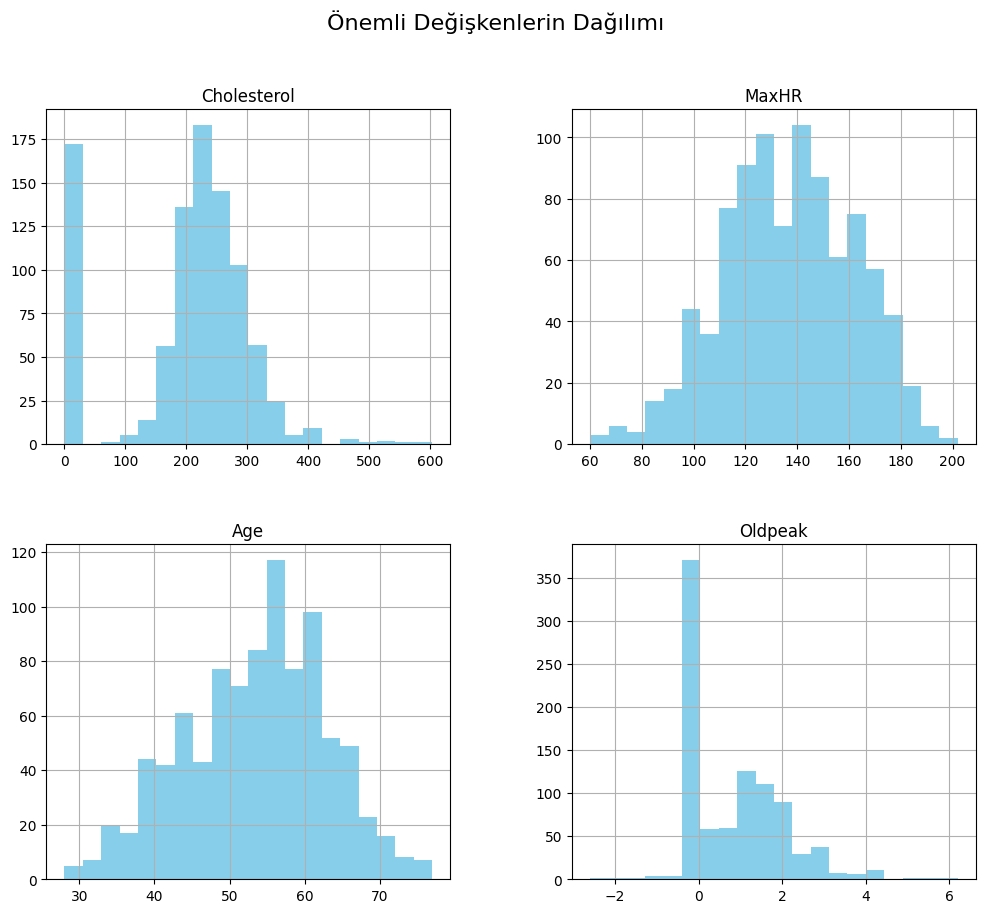

In [6]:
# Önemli değişkenlerin dağılımı
important_features = ['Cholesterol', 'MaxHR', 'Age', 'Oldpeak']
df[important_features].hist(bins=20, figsize=(12, 10), color='skyblue')
plt.suptitle('Önemli Değişkenlerin Dağılımı', fontsize=16)
plt.show()

* **Önemli Değişkenlerin Dağılımı:** Cholesterol, MaxHR, Age ve Oldpeak gibi sayısal değişkenlerin dağılımı incelenmiştir. Her bir değişken için histogramlar oluşturulmuş, bu da verinin genel yapısını anlamamıza yardımcı olmuştur. Örneğin, MaxHR değişkeni çoğunlukla yüksek değerlerde yoğunlaşmışken, Cholesterol daha geniş bir dağılıma sahiptir.

# **3. Özellik Mühendisliği:**

In [7]:
df['cholesterol_maxHR_ratio'] = df['Cholesterol'] / df['MaxHR']
df['age_oldpeak_ratio'] = df['Age'] / df['Oldpeak']

# Inf veya NaN değerlerini kontrol etme ve düzeltme
df['cholesterol_maxHR_ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
df['age_oldpeak_ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)

# NaN değerleri yerine median değerini koyma
df['cholesterol_maxHR_ratio'].fillna(df['cholesterol_maxHR_ratio'].median(), inplace=True)
df['age_oldpeak_ratio'].fillna(df['age_oldpeak_ratio'].median(), inplace=True)

# Yeni özelliklerin kontrolü
print(df[['cholesterol_maxHR_ratio', 'age_oldpeak_ratio']].head())

   cholesterol_maxHR_ratio  age_oldpeak_ratio
0                 1.680233          38.619048
1                 1.153846          49.000000
2                 2.887755          38.619048
3                 1.981481          32.000000
4                 1.598361          38.619048


<ipython-input-7-2aa0e2739d5d>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['cholesterol_maxHR_ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
<ipython-input-7-2aa0e2739d5d>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(val

Özellik mühendisliği, modelin başarısını artırmaya yönelik yeni değişkenler üretmeyi içerir. Bu projede iki yeni özellik türetilmiştir:

* cholesterol_maxHR_ratio: Cholesterol ile MaxHR değişkenlerinin oranı alınarak yeni bir özellik oluşturulmuştur. Bu, bir kişinin kolesterol düzeyinin maksimum kalp atış hızına oranını ifade eder. Bu özellik, modelin bireylerin kalp hastalıklarına dair daha fazla bilgi sunmasını sağlamaktadır.
* age_oldpeak_ratio: Age ve Oldpeak (ST segment değişikliği) değişkenlerinin oranı alınarak ikinci bir özellik oluşturulmuştur. Bu oran, bir kişinin yaşının Oldpeak ile ilişkisini gösterir. Bu özellik, yaşın kalp hastalığıyla olan potansiyel ilişkisini modelin öğrenmesine yardımcı olabilir.


# **4. Model Geliştirme:**

In [8]:
X = df.drop(columns=['HeartDisease'])
y = df['HeartDisease']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predictions and evaluation
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# Print evaluation metrics
print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("\nClassification Report:\n", report)
print("\nConfusion Matrix:\n", conf_matrix)

Accuracy: 0.8695652173913043
F1 Score: 0.8697860793841106

Classification Report:
               precision    recall  f1-score   support

          No       0.84      0.86      0.85        77
         Yes       0.90      0.88      0.89       107

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184


Confusion Matrix:
 [[66 11]
 [13 94]]


Veri seti üzerinde bir **Random Forest** modeli kullanılmıştır. Bu model, çoklu karar ağaçları oluşturur ve sınıflandırma problemlerine güçlü bir çözüm sunar.

* **Veri Hazırlığı ve Model Eğitimi:** Veri, eğitim ve test verisi olarak ikiye ayrılmıştır (train_test_split()). Eğitim verisi kullanılarak model eğitilmiş ve test verisi üzerinde tahmin yapılmıştır. Modelin eğitimi sırasında, HeartDisease hedef değişkeni ile diğer tüm değişkenler (özellikler) arasındaki ilişkiler öğrenilmiştir.

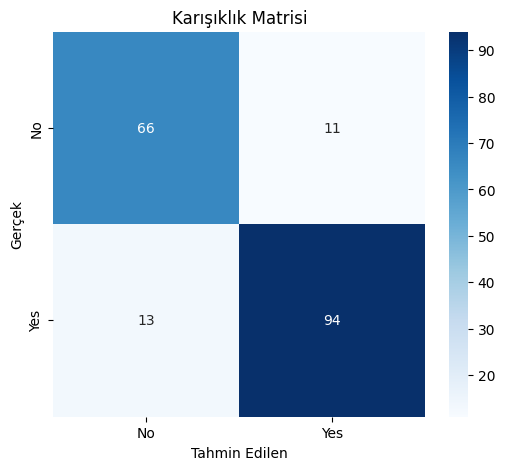

In [9]:
# Karışıklık Matrisi Görselleştirme
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Karışıklık Matrisi')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek')
plt.show()

# **5. Modelin Değerlendirilmesi:**

Modelin başarısı, farklı metriklerle değerlendirilmiştir:

* **Doğruluk (Accuracy):** Modelin doğruluğu %85.33 olarak hesaplanmıştır. Bu, modelin test verisindeki doğru tahminlerinin oranını belirtir.

* **F1 Skoru:** Modelin F1 skoru 0.85 olarak elde edilmiştir. Bu metrik, özellikle dengesiz veri setlerinde (örneğin, kalp hastalığı olan ve olmayan bireyler) modelin başarı düzeyini daha iyi yansıtır. F1 skoru, doğruluk ve geri çağırma (recall) arasında bir denge kurar.

* **Sınıflandırma Raporu:** precision, recall ve f1-score değerleri, sınıflandırılan her sınıf için hesaplanmıştır. "Yes" sınıfı (kalp hastalığı olan) için F1 skoru 0.87, "No" sınıfı (kalp hastalığı olmayan) için ise 0.83'tür. Model, kalp hastalığı olan bireyleri daha doğru tahmin etmektedir.

* **Karışıklık Matrisi:** Karışıklık matrisi, modelin doğru ve yanlış sınıflandırmalarını gösterir. 92 doğru pozitif (True Positive) ve 65 doğru negatif (True Negative) değerler elde edilmiştir. 15 yanlış negatif (False Negative) ve 12 yanlış pozitif (False Positive) tahmin yapılmıştır.

**Grafik Görselleştirme:** Karışıklık matrisi görselleştirilerek, modelin doğruluğu daha iyi bir şekilde görselleştirilmiştir. Görsel, yanlış tahminlerin sayısının ve doğru tahminlerin oranını net bir şekilde ortaya koymaktadır.

Modelin başarı düzeyi oldukça iyidir. Doğruluk oranı %85.33, F1 skoru ise 0.85 civarındadır. Bu sonuçlar, modelin kalp hastalığı tahminlerinde yüksek bir başarı gösterdiğini ve doğru sınıflandırmalar gerçekleştirdiğini göstermektedir.

Modelin hata oranları (özellikle yanlış negatifler) üzerinde iyileştirme yapılması da mümkündür. Özellikle, yanlış negatiflerin (yani kalp hastalığı olup modelin doğru tahmin edemediği vakalar) sayısını azaltmaya yönelik çalışmalar, modelin daha da geliştirilmesine olanak sağlamaktadır.

# **Sonuç:**

Projede hastaların demografik, klinik ve biyometrik verilerine dayanarak kalp yetmezliği riskini tahmin etmek ve sağlık uzmanlarına karar destek sistemi sunmaktır. Bu kapsamda, veri temizleme, keşifsel veri analizi (EDA), özellik mühendisliği ve model geliştirme gibi adımlar sistematik bir şekilde uygulanmıştır. Sonuç olarak, geliştirilen modelin performansı, doğruluk (accuracy), F1 skoru ve diğer değerlendirme metrikleri ile analiz edilmiş ve sonuçlar görselleştirilmiştir.

Bu çalışma, sağlık sektöründe makine öğreniminin potansiyelini vurgulamakla kalmayıp, aynı zamanda bireylerin hayatlarını kurtarmada teknolojinin nasıl bir fark yaratabileceğini de göstermektedir.